# 🥔 Predicción del Precio de la Papa en la Región Puno mediante Redes Neuronales LSTM
### Variables Climáticas y Económicas

**Tesis:** Predicción del Precio de la Papa en la Región Puno Mediante Redes Neuronales LSTM: Con Variables Climáticas y Económicas
**Autora:** Edith Nayely Almanza Mamani — Universidad Nacional del Altiplano, Puno
**Escuela Profesional de Ingeniería de Sistemas**

---

### Objetivo del prototipo

Este notebook implementa el pipeline completo descrito en los objetivos específicos de la tesis:

1. **Integrar** las fuentes de datos meteorológicos (SENAMHI — estación Puente Ilave) y económicos (SISAP‑MIDAGRI, precios mayorista/minorista) en un dataset agrícola unificado y mensual.
2. **Limpiar**, detectar anomalías y explorar (EDA) las series temporales climáticas y de precios.
3. **Diseñar y entrenar** tres arquitecturas LSTM: **Climático exclusivo**, **Económico exclusivo** y **Combinado (multivariado)**.
4. **Validar, comparar e interpretar** el desempeño con MAE, RMSE, MAPE, R² y un análisis de importancia de variables (permutation importance / SHAP), para contrastar la hipótesis de que el modelo combinado predice con mayor precisión.

> ⚠️ **Nota sobre variables económicas:** la tesis contempla también IPC, costos de producción/transporte y volumen de ingreso a mercados (BCRP/INEI). Los archivos entregados para este prototipo (`datos.xlsx`) contienen **precios mayoristas y minoristas mensuales (SISAP‑MIDAGRI)** para 6 variedades de papa. El bloque "económico" de este prototipo se construye por tanto con el precio minorista y componentes autorregresivos (lags, medias móviles) del precio mayorista, que son señales económicas legítimas del mercado. Cuando cuentes con series de IPC/BCRP, solo tienes que añadirlas en la sección **3.2** y quedarán integradas automáticamente al pipeline.

**Cómo usar este notebook:** ejecuta las celdas en orden (`Entorno de ejecución → Ejecutar todas`). En la celda de carga de datos se te pedirá subir `datos.xlsx` y `Puno_ConvencionalMeteorologico.xlsx`.


## 1. Configuración del entorno

In [1]:
# Instalación de librerías (Colab ya trae la mayoría; esto asegura versiones compatibles)
!pip install -q openpyxl ipywidgets shap statsmodels plotly --upgrade
print("Librerías instaladas correctamente ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.3 MB/s eta 0:00:00
Librerías instaladas correctamente ✅


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.outliers_influence import variance_inflation_factor

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titleweight'] = 'bold'

COLOR_MAY = '#8B4513'   # marrón papa - mayorista
COLOR_MIN = '#D2691E'   # marrón claro - minorista
COLOR_CLIMA = '#2E86AB' # azul - clima
COLOR_ECON = '#C73E1D'  # rojo ladrillo - económico
COLOR_COMB = '#3B7A57'  # verde - combinado

def estilo_map(styler):
    """Compat.: pandas nuevo usa .map, pandas viejo (Colab) usa .applymap."""
    return styler.map if hasattr(styler, 'map') else styler.applymap

print(f"TensorFlow {tf.__version__} | GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow 2.20.0 | GPU disponible: False


## 2. Carga de los datasets

Sube los dos archivos entregados:
- **`datos.xlsx`** — Precios mayoristas/minoristas mensuales de 6 variedades de papa (SISAP‑MIDAGRI), hojas por año 2020‑2025.
- **`Puno_ConvencionalMeteorologico.xlsx`** — Registros diarios de temperatura, humedad y precipitación de la estación Puente Ilave (SENAMHI), hojas por año 2020‑2025.


In [3]:
import os

def cargar_archivos():
    # Sube los archivos en Colab, o los busca en el directorio local si ya existen.
    nombres_esperados = ['datos.xlsx', 'Puno_ConvencionalMeteorologico.xlsx']
    faltantes = [n for n in nombres_esperados if not os.path.exists(n)]
    if faltantes:
        try:
            from google.colab import files
            print(f"Sube estos archivos: {faltantes}")
            subidos = files.upload()
            faltantes = [n for n in nombres_esperados if not os.path.exists(n)]
        except ImportError:
            pass
    ok = all(os.path.exists(n) for n in nombres_esperados)
    if ok:
        print("✅ Archivos disponibles:", nombres_esperados)
    else:
        print("⚠️ Faltan archivos:", [n for n in nombres_esperados if not os.path.exists(n)])
    return ok

cargar_archivos()

PRICE_FILE = 'datos.xlsx'
METEO_FILE = 'Puno_ConvencionalMeteorologico.xlsx'


Sube estos archivos: ['Puno_ConvencionalMeteorologico.xlsx']


Saving Puno_ConvencionalMeteorologico.xlsx to Puno_ConvencionalMeteorologico.xlsx
✅ Archivos disponibles: ['datos.xlsx', 'Puno_ConvencionalMeteorologico.xlsx']


## 3. Integración de datos (ETL)

### 3.1. Precios mayoristas y minoristas (SISAP‑MIDAGRI)

El archivo tiene una hoja por año, con un bloque de 6 filas por variedad de papa:
`May. Mínimo / May. Promedio / May. Máximo` (mayorista) y `Min. Mínimo / Min. Promedio / Min. Máximo` (minorista), en columnas Ene‑Dic.

**Hallazgo de calidad de datos:** el valor `0.1` se usa como marcador de *"sin dato de mercado"* (por ejemplo, coincide exactamente con los meses de cuarentena estricta por COVID‑19 en 2020, abril‑agosto). Se trata como dato faltante (`NaN`), no como precio real.


In [4]:
import openpyxl

MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
MES_NUM = {m: i + 1 for i, m in enumerate(MESES)}

def parse_precios(path):
    wb = openpyxl.load_workbook(path, data_only=True)
    records = []
    for sheet_name in wb.sheetnames:
        try:
            anio = int(sheet_name)
        except ValueError:
            continue  # ignora hojas que no representan un año
        ws = wb[sheet_name]
        cur_code, cur_prod = None, None
        for row in ws.iter_rows(min_row=3, max_row=ws.max_row, values_only=True):
            if row[0] is not None and row[1] is not None:
                cur_code, cur_prod = row[0], row[1]
                continue
            if row[1] == 'Kilogramo' and row[4] is not None:
                tipo_precio = row[4]
                for mes, val in zip(MESES, row[5:17]):
                    records.append(dict(codigo=cur_code, producto=cur_prod, anio=anio,
                                         mes=MES_NUM[mes], tipo_precio=tipo_precio, valor=val))
    df = pd.DataFrame(records)
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    df.loc[df['valor'] <= 0.1, 'valor'] = np.nan   # 0.1 = sin dato de mercado
    return df

precios = parse_precios(PRICE_FILE)
print(f"Registros parseados: {len(precios)}")
print(f"Variedades encontradas: {sorted(precios['producto'].unique())}")

# Calidad de datos por variedad (% de meses sin dato de mercado)
calidad = (precios.groupby('producto')['valor']
           .apply(lambda s: s.isna().mean() * 100)
           .sort_values()
           .rename('% de datos faltantes'))
display(calidad.to_frame().style.format("{:.1f}%").background_gradient(cmap='RdYlGn_r'))


Registros parseados: 2592
Variedades encontradas: ['Papa canchan', 'Papa huayro', 'Papa negra andina', 'Papa peruanita', 'Papa unica', 'Papa yungay']


,% de datos faltantes
producto,
Papa negra andina,4.9%
Papa canchan,10.4%
Papa peruanita,10.6%
Papa huayro,16.0%
Papa unica,34.7%
Papa yungay,80.6%


### 3.2. Datos meteorológicos (SENAMHI — Estación Puente Ilave)

Registros diarios con posibles marcas `S/D` (sin dato). Se agregan a nivel mensual:

- `t_max_prom`, `t_min_prom`: temperatura máx./mín. promedio del mes
- `t_min_abs`: temperatura mínima absoluta del mes (riesgo de helada)
- `precip_total`: precipitación acumulada del mes
- `dias_helada`: número de días con temperatura mínima ≤ 0 °C


In [5]:
def parse_meteo(path):
    wb = openpyxl.load_workbook(path, data_only=True)
    frames = []
    for sheet_name in wb.sheetnames:
        ws = wb[sheet_name]
        rows = []
        for row in ws.iter_rows(min_row=8, max_row=ws.max_row, values_only=True):
            if row[0] in (None, ''):
                continue
            rows.append(row[:5])
        frames.append(pd.DataFrame(rows, columns=['fecha', 't_max', 't_min', 'hum_rel', 'precip']))
    df = pd.concat(frames, ignore_index=True)
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    for c in ['t_max', 't_min', 'hum_rel', 'precip']:
        df[c] = pd.to_numeric(df[c], errors='coerce')  # 'S/D' -> NaN
    df = df.dropna(subset=['fecha']).sort_values('fecha').drop_duplicates('fecha')
    df['anio'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    return df

meteo = parse_meteo(METEO_FILE)
print(f"Registros diarios: {len(meteo)}  |  Rango: {meteo['fecha'].min().date()} → {meteo['fecha'].max().date()}")

cobertura = meteo['fecha'].nunique() / len(pd.date_range(meteo['fecha'].min(), meteo['fecha'].max(), freq='D')) * 100
print(f"Cobertura de días con registro en el rango total: {cobertura:.1f}%")
print("\n% de valores faltantes por variable (dentro de los días registrados):")
display((meteo[['t_max','t_min','hum_rel','precip']].isna().mean() * 100).round(1).to_frame('% faltante'))

monthly_clima = meteo.groupby(['anio', 'mes']).agg(
    t_max_prom=('t_max', 'mean'),
    t_min_prom=('t_min', 'mean'),
    t_min_abs=('t_min', 'min'),
    precip_total=('precip', 'sum'),
    dias_helada=('t_min', lambda s: (s <= 0).sum()),
    dias_con_registro=('fecha', 'count')
).reset_index()

monthly_clima.head()


Registros diarios: 1801  |  Rango: 2020-01-01 → 2025-12-31
Cobertura de días con registro en el rango total: 82.2%

% de valores faltantes por variable (dentro de los días registrados):


,% faltante
t_max,11.7
t_min,11.8
hum_rel,20.1
precip,11.0


,anio,mes,t_max_prom,t_min_prom,t_min_abs,precip_total,dias_helada,dias_con_registro
0,2020,1,16.683871,6.974194,4.0,119.3,0,31
1,2020,2,16.275862,7.020690,1.0,205.8,0,29
2,2020,3,15.762500,7.105882,5.4,39.3,0,19
3,2020,4,NaN,NaN,NaN,0.0,0,27
4,2020,5,NaN,NaN,NaN,0.0,0,31


## 4. Construcción del dataset agrícola unificado — las 6 variedades

Se arma un panel **mensual** (2020‑01 a 2025‑12, 72 meses) **para cada una de las 6 variedades de papa**, uniendo precios y clima, y completando con **interpolación temporal lineal** cualquier mes sin dato (incluyendo los meses de cuarentena 2020 y otros vacíos puntuales), preservando la continuidad de la serie que requiere una LSTM.

**Filtro de calidad para el modelado:** una variedad cuyo precio mayorista tiene que ser interpolado en más del 40% de los meses ya no aporta una señal real suficiente para entrenar una LSTM — el modelo terminaría aprendiendo el propio interpolador lineal. Esas variedades se excluyen del modelado (secciones 6‑11) pero siguen disponibles para exploración en el panel interactivo de la sección 5.1.

In [6]:
def construir_panel(producto):
    p = (precios[precios.producto == producto]
         .pivot_table(index=['anio', 'mes'], columns='tipo_precio', values='valor', dropna=False)
         .reset_index())
    p = p.rename(columns={'May. Promedio': 'precio_mayorista', 'Min. Promedio': 'precio_minorista',
                           'May. Minimo': 'may_min', 'May. Maximo': 'may_max',
                           'Min. Minimo': 'min_min', 'Min. Maximo': 'min_max'})

    full_idx = pd.DataFrame([(a, m) for a in range(2020, 2026) for m in range(1, 13)],
                             columns=['anio', 'mes'])
    p = pd.merge(full_idx, p, on=['anio', 'mes'], how='left')
    panel = pd.merge(p, monthly_clima, on=['anio', 'mes'], how='left')
    panel['fecha'] = pd.to_datetime(panel['anio'].astype(str) + '-' + panel['mes'].astype(str) + '-01')
    panel = panel.sort_values('fecha').reset_index(drop=True)

    num_cols = ['precio_mayorista', 'precio_minorista', 'may_min', 'may_max', 'min_min', 'min_max',
                't_max_prom', 't_min_prom', 't_min_abs', 'precip_total', 'dias_helada']
    faltantes_antes = panel[num_cols].isna().sum()
    panel[num_cols] = panel[num_cols].interpolate(method='linear', limit_direction='both')
    return panel, faltantes_antes

VARIEDADES = sorted(precios['producto'].unique())
PRODUCTO_DEFAULT_EDA = 'Papa canchan'  # variedad con mayor volumen comercializado en Puno, usada como ejemplo por defecto

# --- Construir el panel de las 6 variedades y evaluar su calidad de datos ---
paneles = {}
calidad_variedad = []
for producto in VARIEDADES:
    panel_v, faltantes_v = construir_panel(producto)
    paneles[producto] = panel_v
    pct_falt = faltantes_v.get('precio_mayorista', 0) / len(panel_v) * 100
    calidad_variedad.append(dict(variedad=producto,
                                  meses_interpolados=int(faltantes_v.get('precio_mayorista', 0)),
                                  pct_interpolado=pct_falt))

calidad_df = pd.DataFrame(calidad_variedad).sort_values('pct_interpolado').reset_index(drop=True)
UMBRAL_FALTANTES_PCT = 40.0
calidad_df['incluida_en_modelado'] = calidad_df['pct_interpolado'] <= UMBRAL_FALTANTES_PCT

VARIEDADES_MODELABLES = calidad_df.loc[calidad_df['incluida_en_modelado'], 'variedad'].tolist()
VARIEDADES_EXCLUIDAS = calidad_df.loc[~calidad_df['incluida_en_modelado'], 'variedad'].tolist()

print(f"Panel mensual construido para las {len(VARIEDADES)} variedades (2020‑01 a 2025‑12, 72 meses c/u).\n")
print(f"✅ Variedades incluidas en el modelado LSTM ({len(VARIEDADES_MODELABLES)}): {VARIEDADES_MODELABLES}")
if VARIEDADES_EXCLUIDAS:
    print(f"⚠️ Variedades EXCLUIDAS del modelado por baja cobertura de datos "
          f"(>{UMBRAL_FALTANTES_PCT:.0f}% de meses interpolados): {VARIEDADES_EXCLUIDAS}")
    print("   (siguen disponibles para exploración en el panel interactivo de la sección 5.1)")

display(calidad_df.style.format({'pct_interpolado': '{:.1f}%'})
        .background_gradient(cmap='RdYlGn_r', subset=['pct_interpolado'])
        .apply(lambda col: ['background-color:#d4edda' if v else 'background-color:#f8d7da' for v in col],
               subset=['incluida_en_modelado']))

Panel mensual construido para las 6 variedades (2020‑01 a 2025‑12, 72 meses c/u).

✅ Variedades incluidas en el modelado LSTM (5): ['Papa negra andina', 'Papa canchan', 'Papa peruanita', 'Papa huayro', 'Papa unica']
⚠️ Variedades EXCLUIDAS del modelado por baja cobertura de datos (>40% de meses interpolados): ['Papa yungay']
   (siguen disponibles para exploración en el panel interactivo de la sección 5.1)


,variedad,meses_interpolados,pct_interpolado,incluida_en_modelado
0,Papa negra andina,4,5.6%,True
1,Papa canchan,8,11.1%,True
2,Papa peruanita,8,11.1%,True
3,Papa huayro,12,16.7%,True
4,Papa unica,25,34.7%,True
5,Papa yungay,58,80.6%,False


## 5. Análisis Exploratorio de Datos (EDA)

### 5.1. Panel interactivo de exploración

Selecciona la variedad de papa para explorar su serie de precios y clima (incluye las variedades excluidas del modelado, para inspeccionar por qué).

In [7]:
selector_variedad = widgets.Dropdown(options=VARIEDADES, value=PRODUCTO_DEFAULT_EDA, description='Variedad:')
out_eda = widgets.Output()

def graficar_serie(producto):
    with out_eda:
        clear_output(wait=True)
        pnl = paneles[producto]
        if producto in VARIEDADES_EXCLUIDAS:
            print(f"⚠️ '{producto}' está excluida del modelado LSTM "
                  f"({calidad_df.set_index('variedad').loc[producto, 'pct_interpolado']:.1f}% de meses interpolados).")

        fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

        axes[0].plot(pnl['fecha'], pnl['precio_mayorista'], color=COLOR_MAY, lw=2, label='Mayorista (promedio)')
        axes[0].plot(pnl['fecha'], pnl['precio_minorista'], color=COLOR_MIN, lw=2, ls='--', label='Minorista (promedio)')
        axes[0].set_title(f'Precio mensual de {producto} — S//kg')
        axes[0].legend(); axes[0].set_ylabel('S/ por kg')

        axes[1].plot(pnl['fecha'], pnl['t_max_prom'], color='#E63946', label='T° máx. promedio')
        axes[1].plot(pnl['fecha'], pnl['t_min_prom'], color=COLOR_CLIMA, label='T° mín. promedio')
        axes[1].fill_between(pnl['fecha'], pnl['t_min_prom'], pnl['t_max_prom'], color=COLOR_CLIMA, alpha=0.08)
        axes[1].set_title('Temperatura mensual — Estación Puente Ilave')
        axes[1].legend(); axes[1].set_ylabel('°C')

        axes[2].bar(pnl['fecha'], pnl['precip_total'], width=20, color=COLOR_CLIMA, alpha=0.6, label='Precipitación total')
        ax2b = axes[2].twinx()
        ax2b.plot(pnl['fecha'], pnl['dias_helada'], color='#6A0572', marker='o', ms=3, label='Días con helada')
        axes[2].set_title('Precipitación mensual y días con helada')
        axes[2].set_ylabel('mm'); ax2b.set_ylabel('días de helada')
        lines1, labels1 = axes[2].get_legend_handles_labels()
        lines2, labels2 = ax2b.get_legend_handles_labels()
        axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

        plt.tight_layout(); plt.show()

def on_change(change):
    graficar_serie(change['new'])

selector_variedad.observe(on_change, names='value')
display(selector_variedad, out_eda)
graficar_serie(PRODUCTO_DEFAULT_EDA)

Dropdown(description='Variedad:', options=('Papa canchan', 'Papa huayro', 'Papa negra andina', 'Papa peruanita…

Output()

### 5.2. Estacionalidad del precio — las 5 variedades modeladas

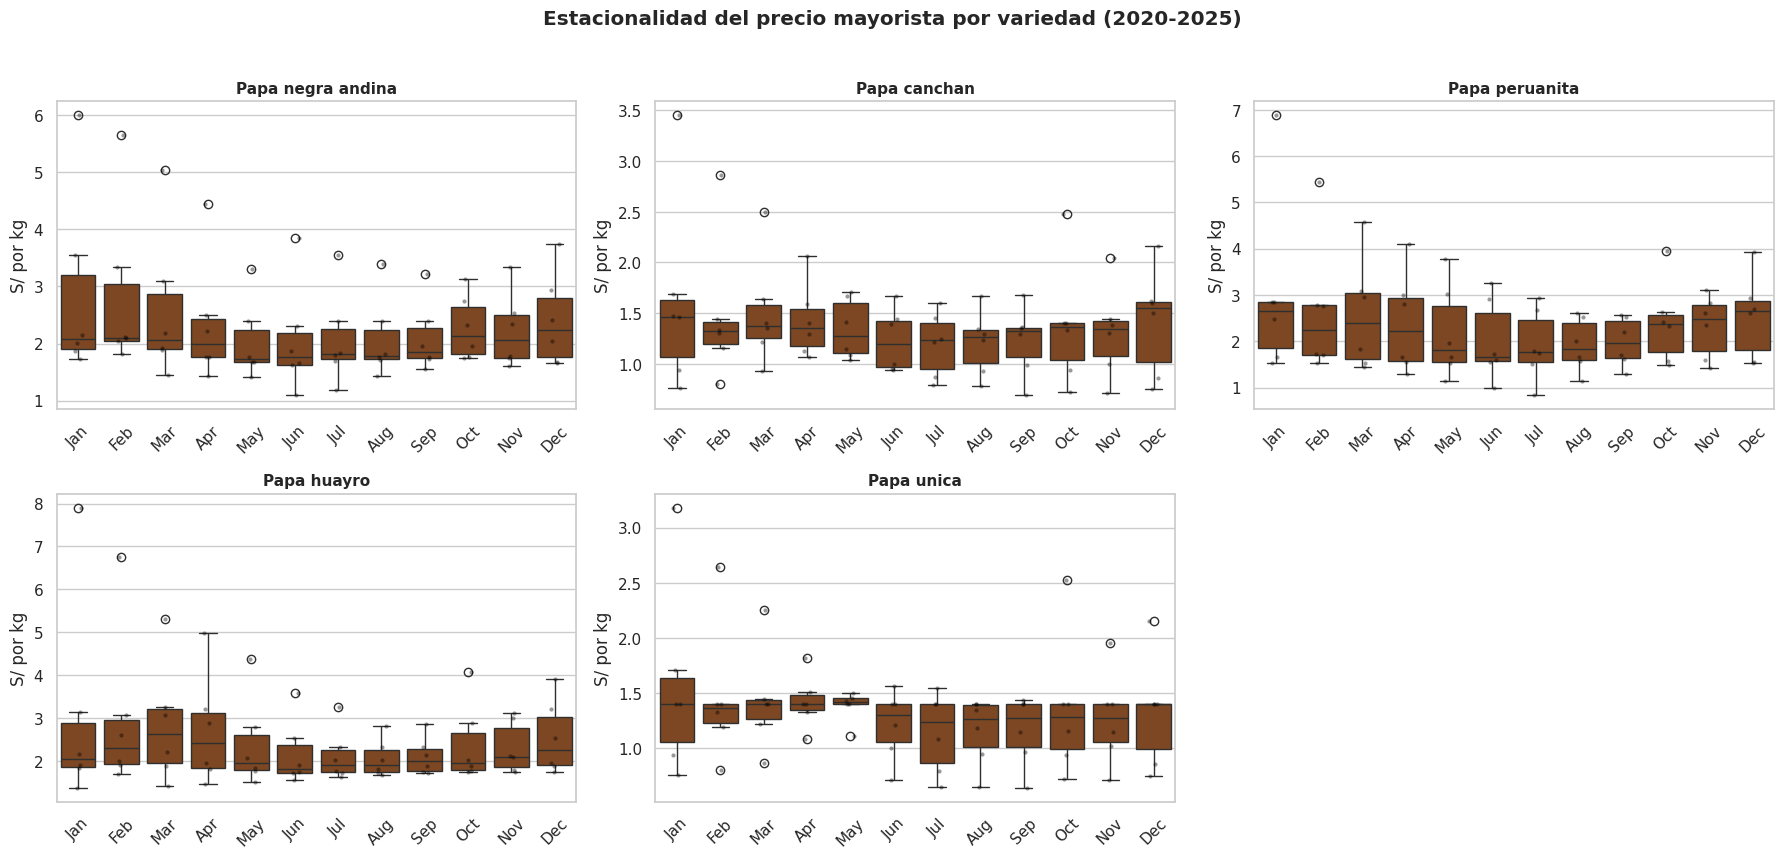

Interpretación: los meses con cajas más altas concentran los precios pico (típicamente antes de la cosecha grande, abr‑may), mientras que los meses posteriores a la cosecha muestran precios más bajos y estables. El patrón se repite de forma consistente entre variedades, aunque con distinta amplitud.


In [8]:
orden_meses = pd.date_range('2024-01-01', periods=12, freq='MS').strftime('%b')
n_var = len(VARIEDADES_MODELABLES)
ncols = 3
nrows = int(np.ceil(n_var / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.2 * nrows), squeeze=False)

for i, producto in enumerate(VARIEDADES_MODELABLES):
    ax = axes[i // ncols][i % ncols]
    pnl = paneles[producto].copy()
    pnl['mes_nombre'] = pnl['fecha'].dt.strftime('%b')
    sns.boxplot(data=pnl, x='mes_nombre', y='precio_mayorista', order=orden_meses, color=COLOR_MAY, ax=ax)
    sns.stripplot(data=pnl, x='mes_nombre', y='precio_mayorista', order=orden_meses, color='black', alpha=0.4, size=3, ax=ax)
    ax.set_title(producto, fontsize=11)
    ax.set_xlabel(''); ax.set_ylabel('S/ por kg')
    ax.tick_params(axis='x', rotation=45)

for j in range(n_var, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.suptitle('Estacionalidad del precio mayorista por variedad (2020‑2025)', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()

print("Interpretación: los meses con cajas más altas concentran los precios pico (típicamente antes de la",
      "cosecha grande, abr‑may), mientras que los meses posteriores a la cosecha muestran precios más bajos y estables.",
      "El patrón se repite de forma consistente entre variedades, aunque con distinta amplitud.")

### 5.3. Descomposición estacional (tendencia, estacionalidad, residuo) — las 5 variedades modeladas

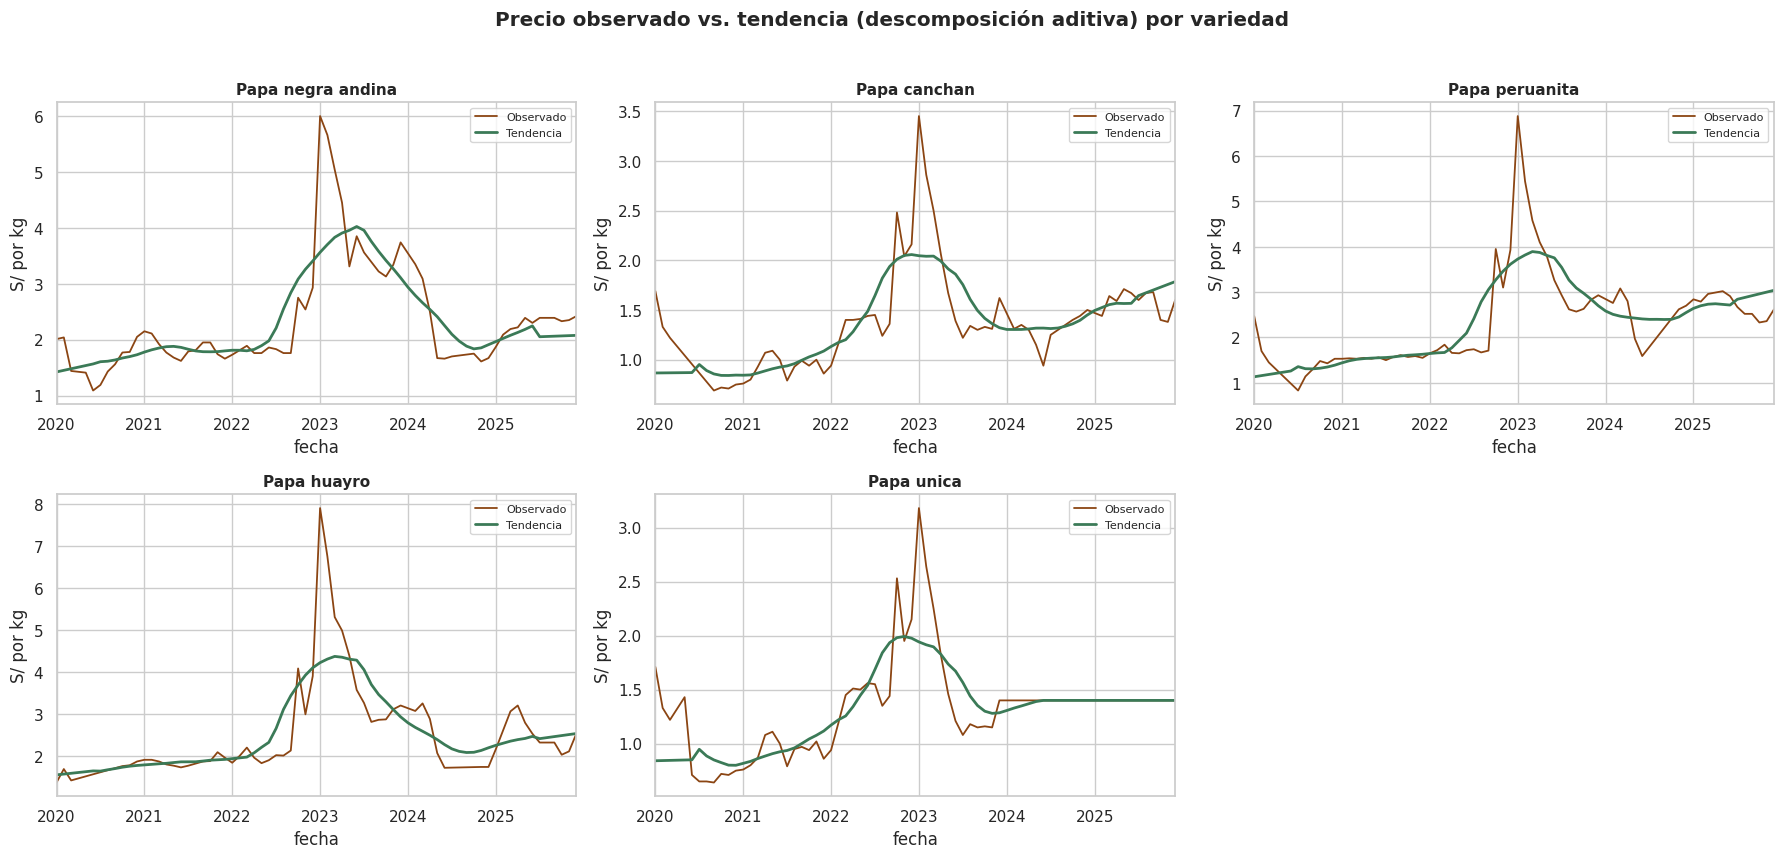

Nota: se muestra observado + tendencia por variedad para comparar de un vistazo; el componente estacional y el residuo pueden inspeccionarse variedad por variedad en el panel interactivo de la sección 5.1.


In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.2 * nrows), squeeze=False)

for i, producto in enumerate(VARIEDADES_MODELABLES):
    ax = axes[i // ncols][i % ncols]
    serie = paneles[producto].set_index('fecha')['precio_mayorista']
    decomposicion = seasonal_decompose(serie, model='additive', period=12, extrapolate_trend='freq')
    decomposicion.observed.plot(ax=ax, color=COLOR_MAY, lw=1.3, label='Observado')
    decomposicion.trend.plot(ax=ax, color=COLOR_COMB, lw=2, label='Tendencia')
    ax.set_title(producto, fontsize=11)
    ax.set_ylabel('S/ por kg')
    ax.legend(fontsize=8)

for j in range(n_var, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.suptitle('Precio observado vs. tendencia (descomposición aditiva) por variedad', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()
print("Nota: se muestra observado + tendencia por variedad para comparar de un vistazo; el componente estacional",
      "y el residuo pueden inspeccionarse variedad por variedad en el panel interactivo de la sección 5.1.")

### 5.4. Correlación entre variables climáticas y precio — comparación entre variedades

### 5.4.1. Matriz de correlación enfocada en clima y precios — por variedad

La celda anterior muestra un solo **vector** de correlación (cada variable climática vs. el precio
mayorista). Aquí se construye la **matriz de correlación completa** (cuadrada, simétrica) restringida
solo a las variables realmente relevantes — clima (`t_max_prom`, `t_min_prom`, `t_min_abs`,
`precip_total`, `dias_helada`) y **ambos precios** (`precio_mayorista`, `precio_minorista`) — sin mezclar
con lags, medias móviles ni variables cíclicas del mes (eso se deja para la sección 6). Se genera una
matriz por variedad para poder comparar, además de "clima vs. precio", cómo se relacionan las propias
variables climáticas entre sí (p. ej. `t_max_prom` y `t_min_abs`) y cómo se relacionan `precio_mayorista`
y `precio_minorista` entre sí, dentro de cada variedad.


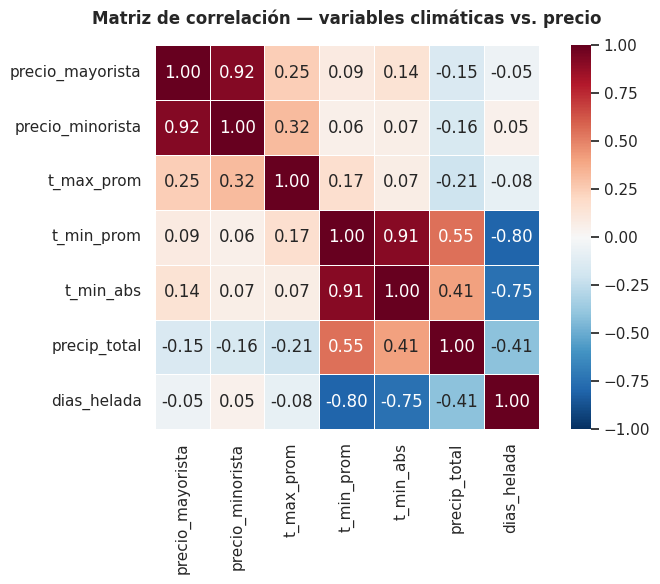

Correlación del precio mayorista con cada variable climática (ordenada por fuerza de impacto):


,correlación
t_max_prom,0.25
precip_total,-0.15
t_min_abs,0.14
t_min_prom,0.09
dias_helada,-0.05


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir columnas
cols_corr = ['precio_mayorista', 'precio_minorista', 't_max_prom', 't_min_prom', 't_min_abs',
             'precip_total', 'dias_helada']

# Definir explícitamente cuáles de estas son variables climáticas para el reporte
cols_climaticas = ['t_max_prom', 't_min_prom', 't_min_abs', 'precip_total', 'dias_helada']

# 2. Calcular la matriz de correlación
corr = panel[cols_corr].corr()

# 3. Graficar la matriz de correlación completa (7x7)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación — variables climáticas vs. precio', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 4. Reporte corregido: Solo variables climáticas reales frente al precio mayorista
print("Correlación del precio mayorista con cada variable climática (ordenada por fuerza de impacto):")

# Filtramos la matriz para que solo muestre las climáticas frente a 'precio_mayorista'
reporte_climaticas = (corr.loc[cols_climaticas, 'precio_mayorista']
                      .sort_values(key=abs, ascending=False)
                      .to_frame('correlación'))

# Mostrar la tabla estilizada con un degradado sutil
display(reporte_climaticas.style.format('{:.2f}').background_gradient(cmap='RdYlGn', vmin=-1, vmax=1))

## 6. Ingeniería de características

Se construyen, para cada una de las variedades modelables:
- **Lags** (1, 2 y 3 meses) del precio mayorista y minorista — capturan inercia del mercado.
- **Media móvil** de 3 meses del precio mayorista — suaviza ruido de corto plazo.
- **Codificación cíclica del mes** (`sin`/`cos`) — representa la estacionalidad sin discontinuidad diciembre→enero.

Y se agrupan en **tres conjuntos de variables** (idénticos para todas las variedades, para que la comparación entre ellas sea justa): **Climático**, **Económico** y **Combinado**, tal como pide el objetivo específico 3 de la tesis.

In [33]:
def generar_features(panel):
    df = panel.copy()
    for lag in [1, 2, 3]:
        df[f'precio_mayorista_lag{lag}'] = df['precio_mayorista'].shift(lag)
        df[f'precio_minorista_lag{lag}'] = df['precio_minorista'].shift(lag)
    df['precio_mayorista_roll3'] = df['precio_mayorista'].rolling(3).mean()
    df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)
    df = df.drop(columns=['dias_con_registro', 'mes_nombre'], errors='ignore').dropna().reset_index(drop=True)
    return df

# --- Definición de los 3 conjuntos de variables (comunes a todas las variedades) ---
CLIMA_VARS = ['t_max_prom', 't_min_prom', 't_min_abs', 'precip_total', 'dias_helada', 'mes_sin', 'mes_cos']

ECON_VARS = ['precio_minorista', 'precio_mayorista_lag1', 'precio_mayorista_lag2', 'precio_mayorista_lag3',
             'precio_minorista_lag1', 'precio_mayorista_roll3', 'mes_sin', 'mes_cos']

COMBINADO_VARS = list(dict.fromkeys(CLIMA_VARS + ECON_VARS))  # unión sin duplicados
TARGET = 'precio_mayorista'

paneles_model = {producto: generar_features(paneles[producto]) for producto in VARIEDADES_MODELABLES}

print(f"Modelo CLIMÁTICO   ({len(CLIMA_VARS)} variables): {CLIMA_VARS}")
print(f"Modelo ECONÓMICO   ({len(ECON_VARS)} variables): {ECON_VARS}")
print(f"Modelo COMBINADO   ({len(COMBINADO_VARS)} variables): {COMBINADO_VARS}")

print("\nObservaciones utilizables por variedad tras generar lags (se pierden las primeras filas):")
display(pd.DataFrame({'variedad': VARIEDADES_MODELABLES,
                       'observaciones': [len(paneles_model[v]) for v in VARIEDADES_MODELABLES]}).set_index('variedad'))

Modelo CLIMÁTICO   (7 variables): ['t_max_prom', 't_min_prom', 't_min_abs', 'precip_total', 'dias_helada', 'mes_sin', 'mes_cos']
Modelo ECONÓMICO   (8 variables): ['precio_minorista', 'precio_mayorista_lag1', 'precio_mayorista_lag2', 'precio_mayorista_lag3', 'precio_minorista_lag1', 'precio_mayorista_roll3', 'mes_sin', 'mes_cos']
Modelo COMBINADO   (13 variables): ['t_max_prom', 't_min_prom', 't_min_abs', 'precip_total', 'dias_helada', 'mes_sin', 'mes_cos', 'precio_minorista', 'precio_mayorista_lag1', 'precio_mayorista_lag2', 'precio_mayorista_lag3', 'precio_minorista_lag1', 'precio_mayorista_roll3']

Observaciones utilizables por variedad tras generar lags (se pierden las primeras filas):


,observaciones
variedad,
Papa negra andina,69
Papa canchan,69
Papa peruanita,69
Papa huayro,69
Papa unica,69


### 6.1. Factor de Inflación de la Varianza (VIF) — diagnóstico de multicolinealidad, por variedad

In [14]:
def resaltar_vif(v):
    color = '#ffcccc' if v > 10 else ('#fff3cd' if v > 5 else '#d4edda')
    return f'background-color: {color}'

vif_tabla = {}
for producto in VARIEDADES_MODELABLES:
    X_vif = paneles_model[producto][COMBINADO_VARS]
    vif_tabla[producto] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_df = pd.DataFrame(vif_tabla, index=COMBINADO_VARS)
display(estilo_map(vif_df.style)(resaltar_vif).format('{:.1f}'))

print("VIF > 10 sugiere alta multicolinealidad. Es esperable que los lags del mismo precio estén correlacionados",
      "entre sí en TODAS las variedades; la LSTM maneja razonablemente esta redundancia, pero queda documentado",
      "para la sección de discusión.")

,Papa negra andina,Papa canchan,Papa peruanita,Papa huayro,Papa unica
t_max_prom,72.8,86.3,68.0,78.6,99.9
t_min_prom,93.1,83.1,69.5,82.2,94.8
t_min_abs,11.8,11.6,12.9,12.6,11.5
precip_total,3.1,2.7,3.0,3.1,2.7
dias_helada,4.9,4.8,4.7,4.6,5.3
mes_sin,3.5,3.7,3.6,4.0,4.1
mes_cos,7.3,6.1,6.4,6.1,5.9
precio_minorista,554.6,103.9,311.8,106.4,1829.8
precio_mayorista_lag1,1698.8,300.5,844.2,360.8,3813.6
precio_mayorista_lag2,610.6,162.4,356.9,133.2,983.8


VIF > 10 sugiere alta multicolinealidad. Es esperable que los lags del mismo precio estén correlacionados entre sí en TODAS las variedades; la LSTM maneja razonablemente esta redundancia, pero queda documentado para la sección de discusión.


## 7. Preparación de secuencias para las LSTM

- **Ventana deslizante** de `WINDOW = 3` meses para predecir el mes siguiente.
- **División temporal** 70% train / 15% validación / 15% test, **sin mezclar el orden** (a diferencia de un split aleatorio, respeta que el futuro no debe usarse para predecir el pasado).
- El escalador (`MinMaxScaler`) se **ajusta solo con el conjunto de entrenamiento** y se aplica igual a validación y test, para evitar fuga de información (*data leakage*).
- Este proceso se repite igual para **cada una de las 5 variedades modelables**, generando un conjunto de datos independiente por variedad y por modelo (Climático / Económico / Combinado).

In [15]:
WINDOW = 3

def crear_secuencias(df, feature_cols, target_col, window=WINDOW):
    X_raw = df[feature_cols].values.astype(float)
    y_raw = df[[target_col]].values.astype(float)
    Xs, ys = [], []
    for i in range(window, len(df)):
        Xs.append(X_raw[i - window:i])
        ys.append(y_raw[i])
    return np.array(Xs), np.array(ys)

def dividir_train_val_test(X, y, train_frac=0.70, val_frac=0.15):
    n = len(X)
    n_tr = int(n * train_frac)
    n_val = int(n * val_frac)
    return (X[:n_tr], y[:n_tr]), (X[n_tr:n_tr + n_val], y[n_tr:n_tr + n_val]), (X[n_tr + n_val:], y[n_tr + n_val:])

def escalar_sin_fuga(Xtr, Xval, Xte, ytr, yval, yte):
    n_feat = Xtr.shape[2]
    fs = MinMaxScaler().fit(Xtr.reshape(-1, n_feat))
    ts = MinMaxScaler().fit(ytr)
    def tx(X):
        shp = X.shape
        return fs.transform(X.reshape(-1, shp[2])).reshape(shp)
    return tx(Xtr), tx(Xval), tx(Xte), ts.transform(ytr), ts.transform(yval), ts.transform(yte), fs, ts

def preparar_dataset(df, feature_cols, target_col=TARGET, window=WINDOW):
    X, y = crear_secuencias(df, feature_cols, target_col, window)
    (Xtr, ytr), (Xval, yval), (Xte, yte) = dividir_train_val_test(X, y)
    Xtr, Xval, Xte, ytr, yval, yte, fs, ts = escalar_sin_fuga(Xtr, Xval, Xte, ytr, yval, yte)
    return dict(Xtr=Xtr, ytr=ytr, Xval=Xval, yval=yval, Xte=Xte, yte=yte, fs=fs, ts=ts)

datasets = {}
resumen_shapes = []
for producto in VARIEDADES_MODELABLES:
    datasets[producto] = {
        'Climático': preparar_dataset(paneles_model[producto], CLIMA_VARS),
        'Económico': preparar_dataset(paneles_model[producto], ECON_VARS),
        'Combinado': preparar_dataset(paneles_model[producto], COMBINADO_VARS),
    }
    for nombre, d in datasets[producto].items():
        resumen_shapes.append(dict(variedad=producto, modelo=nombre,
                                    train=d['Xtr'].shape[0], val=d['Xval'].shape[0], test=d['Xte'].shape[0]))

display(pd.DataFrame(resumen_shapes).set_index(['variedad', 'modelo']))

train  val  test
variedad          modelo                     
Papa negra andina Climático     46    9    11
                  Económico     46    9    11
                  Combinado     46    9    11
Papa canchan      Climático     46    9    11
                  Económico     46    9    11
                  Combinado     46    9    11
Papa peruanita    Climático     46    9    11
                  Económico     46    9    11
                  Combinado     46    9    11
Papa huayro       Climático     46    9    11
                  Económico     46    9    11
                  Combinado     46    9    11
Papa unica        Climático     46    9    11
                  Económico     46    9    11
                  Combinado     46    9    11

## 8. Arquitecturas LSTM: Climático, Económico y Combinado — todas las variedades

Los tres modelos comparten la misma arquitectura (para que la comparación sea justa) y solo difieren en las variables de entrada, tal como pide el objetivo específico 3 de la tesis. Este bloque entrena los tres modelos **para cada una de las 5 variedades modelables** (15 entrenamientos en total).

Se agrega además, más adelante, un **modelo de referencia (baseline) de persistencia** — "el precio del próximo mes será igual al del mes actual" — un estándar mínimo que cualquier modelo debe superar para justificar su uso.

In [16]:
def construir_lstm(input_shape, seed=SEED):
    tf.random.set_seed(seed)
    modelo = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(24, return_sequences=True),
        layers.Dropout(0.25),
        layers.LSTM(12),
        layers.Dense(8, activation='relu'),
        layers.Dense(1)
    ])
    modelo.compile(optimizer=optimizers.Adam(learning_rate=0.005), loss='mse', metrics=['mae'])
    return modelo

def entrenar_modelo(d, nombre, epochs=200, batch_size=8, verbose=0):
    modelo = construir_lstm((d['Xtr'].shape[1], d['Xtr'].shape[2]))
    es = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
    historia = modelo.fit(d['Xtr'], d['ytr'], validation_data=(d['Xval'], d['yval']),
                           epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[es])
    print(f"[{nombre}] entrenamiento detenido en la época {len(historia.history['loss'])} "
          f"(mejor val_loss={min(historia.history['val_loss']):.4f})")
    return modelo, historia

colores = {'Climático': COLOR_CLIMA, 'Económico': COLOR_ECON, 'Combinado': COLOR_COMB}

modelos, historias = {}, {}
for producto in VARIEDADES_MODELABLES:
    print(f"\n### Entrenando variedad: {producto} ###")
    modelos[producto], historias[producto] = {}, {}
    for nombre, d in datasets[producto].items():
        modelos[producto][nombre], historias[producto][nombre] = entrenar_modelo(d, f"{producto} — {nombre}")


### Entrenando variedad: Papa negra andina ###
[Papa negra andina — Climático] entrenamiento detenido en la época 28 (mejor val_loss=0.0247)
[Papa negra andina — Económico] entrenamiento detenido en la época 26 (mejor val_loss=0.0044)
[Papa negra andina — Combinado] entrenamiento detenido en la época 26 (mejor val_loss=0.0025)

### Entrenando variedad: Papa canchan ###
[Papa canchan — Climático] entrenamiento detenido en la época 36 (mejor val_loss=0.0018)
[Papa canchan — Económico] entrenamiento detenido en la época 29 (mejor val_loss=0.0026)
[Papa canchan — Combinado] entrenamiento detenido en la época 39 (mejor val_loss=0.0032)

### Entrenando variedad: Papa peruanita ###
[Papa peruanita — Climático] entrenamiento detenido en la época 39 (mejor val_loss=0.0013)
[Papa peruanita — Económico] entrenamiento detenido en la época 37 (mejor val_loss=0.0024)
[Papa peruanita — Combinado] entrenamiento detenido en la época 40 (mejor val_loss=0.0033)

### Entrenando variedad: Papa huayro ###


### 8.1. Curvas de entrenamiento — por variedad

In [17]:
selector_variedad_modelo = widgets.Dropdown(options=VARIEDADES_MODELABLES, value=VARIEDADES_MODELABLES[0],
                                             description='Variedad:')
out_curvas = widgets.Output()

def graficar_curvas(producto):
    with out_curvas:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
        for ax, (nombre, hist) in zip(axes, historias[producto].items()):
            ax.plot(hist.history['loss'], label='Entrenamiento', color=colores[nombre])
            ax.plot(hist.history['val_loss'], label='Validación', color=colores[nombre], ls='--', alpha=0.7)
            ax.set_title(f'Modelo {nombre}')
            ax.set_xlabel('Época'); ax.legend()
        axes[0].set_ylabel('MSE (escala normalizada)')
        plt.suptitle(f'Curvas de pérdida — {producto}', y=1.03, fontweight='bold')
        plt.tight_layout(); plt.show()

def on_change_curvas(change):
    graficar_curvas(change['new'])

selector_variedad_modelo.observe(on_change_curvas, names='value')
display(selector_variedad_modelo, out_curvas)
graficar_curvas(VARIEDADES_MODELABLES[0])

Dropdown(description='Variedad:', options=('Papa negra andina', 'Papa canchan', 'Papa peruanita', 'Papa huayro…

Output()

## 9. Evaluación y comparación de modelos — todas las variedades

Métricas exigidas por la tesis: **MAE, RMSE, MAPE y R²**, calculadas sobre el conjunto de **test** (datos nunca vistos durante el entrenamiento), en la escala original (S//kg), para cada variedad y cada modelo, incluyendo el baseline de persistencia.

In [18]:
def evaluar(modelo, d):
    pred_esc = modelo.predict(d['Xte'], verbose=0)
    pred = d['ts'].inverse_transform(pred_esc).flatten()
    real = d['ts'].inverse_transform(d['yte']).flatten()
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    r2 = r2_score(real, pred)
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, R2=r2), real, pred

resultados, predicciones = {}, {}
for producto in VARIEDADES_MODELABLES:
    resultados[producto], predicciones[producto] = {}, {}
    for nombre, modelo in modelos[producto].items():
        metricas, real, pred = evaluar(modelo, datasets[producto][nombre])
        resultados[producto][nombre] = metricas
        predicciones[producto][nombre] = dict(real=real, pred=pred)

    # --- Baseline de persistencia (misma partición temporal que los modelos) ---
    panel_model = paneles_model[producto]
    n = len(panel_model); n_tr = int(n * 0.70); n_val = int(n * 0.15)
    serie_precio = panel_model['precio_mayorista'].values
    idx_test_start = WINDOW + n_tr + n_val
    y_test_real = serie_precio[idx_test_start:]
    y_test_persist = serie_precio[idx_test_start - 1: -1]
    mae_p = mean_absolute_error(y_test_real, y_test_persist)
    rmse_p = np.sqrt(mean_squared_error(y_test_real, y_test_persist))
    mape_p = np.mean(np.abs((y_test_real - y_test_persist) / y_test_real)) * 100
    r2_p = r2_score(y_test_real, y_test_persist)
    resultados[producto]['Baseline (persistencia)'] = dict(MAE=mae_p, RMSE=rmse_p, MAPE=mape_p, R2=r2_p)

filas = [dict(Variedad=producto, Modelo=modelo, **m)
         for producto in VARIEDADES_MODELABLES for modelo, m in resultados[producto].items()]
tabla_resultados = pd.DataFrame(filas).set_index(['Variedad', 'Modelo'])[['MAE', 'RMSE', 'MAPE', 'R2']]
tabla_resultados.columns = ['MAE (S//kg)', 'RMSE (S//kg)', 'MAPE (%)', 'R²']

display(tabla_resultados.style.format('{:.3f}')
        .background_gradient(cmap='RdYlGn_r', subset=['MAE (S//kg)', 'RMSE (S//kg)', 'MAPE (%)'])
        .background_gradient(cmap='RdYlGn', subset=['R²']))

print("\n📌 Modelo con menor error (MAE) en el conjunto de test, por variedad:")
mejores = {}
for producto in VARIEDADES_MODELABLES:
    sub = tabla_resultados.loc[producto].drop('Baseline (persistencia)', errors='ignore')
    mejores[producto] = sub['MAE (S//kg)'].idxmin()
    print(f"   {producto}: {mejores[producto]}")


📌 Modelo con menor error (MAE) en el conjunto de test, por variedad:
   Papa negra andina: Climático
   Papa canchan: Económico
   Papa peruanita: Económico
   Papa huayro: Económico
   Papa unica: Económico


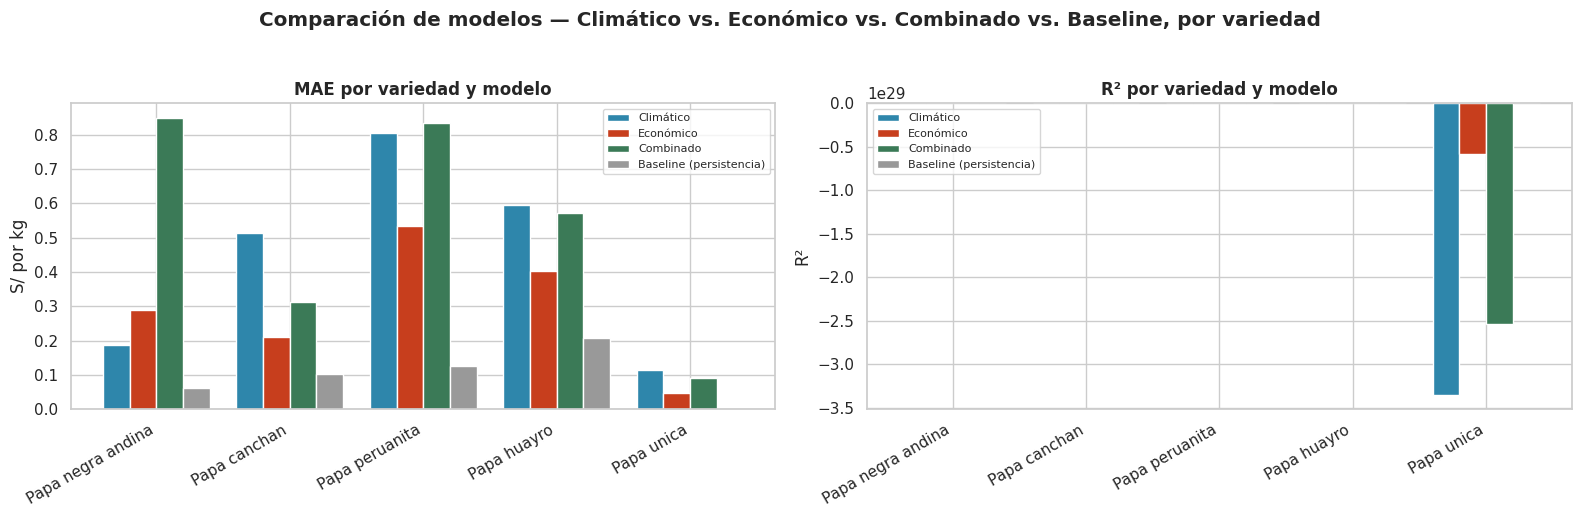

In [19]:
modelos_orden = ['Climático', 'Económico', 'Combinado', 'Baseline (persistencia)']
colores_barras = {'Climático': COLOR_CLIMA, 'Económico': COLOR_ECON, 'Combinado': COLOR_COMB,
                   'Baseline (persistencia)': '#999999'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(VARIEDADES_MODELABLES))
ancho = 0.2

for i, modelo in enumerate(modelos_orden):
    valores_mae = [tabla_resultados.loc[(v, modelo), 'MAE (S//kg)'] for v in VARIEDADES_MODELABLES]
    valores_r2 = [tabla_resultados.loc[(v, modelo), 'R²'] for v in VARIEDADES_MODELABLES]
    axes[0].bar(x + (i - 1.5) * ancho, valores_mae, width=ancho, label=modelo, color=colores_barras[modelo])
    axes[1].bar(x + (i - 1.5) * ancho, valores_r2, width=ancho, label=modelo, color=colores_barras[modelo])

for ax, titulo, ylabel in zip(axes, ['MAE por variedad y modelo', 'R² por variedad y modelo'],
                               ['S/ por kg', 'R²']):
    ax.set_xticks(x); ax.set_xticklabels(VARIEDADES_MODELABLES, rotation=30, ha='right')
    ax.set_title(titulo); ax.set_ylabel(ylabel); ax.legend(fontsize=8)

plt.suptitle('Comparación de modelos — Climático vs. Económico vs. Combinado vs. Baseline, por variedad', y=1.03, fontweight='bold')
plt.tight_layout(); plt.show()

### 9.1. Predicción vs. valor real (conjunto de test) — por variedad

In [20]:
selector_variedad_pred = widgets.Dropdown(options=VARIEDADES_MODELABLES, value=VARIEDADES_MODELABLES[0],
                                           description='Variedad:')
out_pred_test = widgets.Output()

def graficar_pred_vs_real(producto):
    with out_pred_test:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
        for ax, (nombre, p) in zip(axes, predicciones[producto].items()):
            x = np.arange(len(p['real']))
            ax.plot(x, p['real'], 'o-', color='black', label='Real', lw=2)
            ax.plot(x, p['pred'], 's--', color=colores[nombre], label='Predicho', lw=2)
            ax.set_title(f'{nombre}  (MAE={resultados[producto][nombre]["MAE"]:.2f})')
            ax.set_xlabel('Meses en el conjunto de test'); ax.legend()
        axes[0].set_ylabel('Precio mayorista (S//kg)')
        plt.suptitle(f'Precio real vs. predicho por modelo — {producto}', y=1.03, fontweight='bold')
        plt.tight_layout(); plt.show()

def on_change_pred(change):
    graficar_pred_vs_real(change['new'])

selector_variedad_pred.observe(on_change_pred, names='value')
display(selector_variedad_pred, out_pred_test)
graficar_pred_vs_real(VARIEDADES_MODELABLES[0])

Dropdown(description='Variedad:', options=('Papa negra andina', 'Papa canchan', 'Papa peruanita', 'Papa huayro…

Output()

### 9.2. Contraste de hipótesis

> **H0:** no hay diferencia significativa entre el modelo combinado y los modelos univariados.
> **H1:** el modelo combinado tiene mejor desempeño que los modelos univariados.

Se evalúa el contraste **variedad por variedad** y se agrega un resumen general.

In [21]:
filas_hip = []
for producto in VARIEDADES_MODELABLES:
    mae_comb = resultados[producto]['Combinado']['MAE']
    mae_clima = resultados[producto]['Climático']['MAE']
    mae_econ = resultados[producto]['Económico']['MAE']
    mejora_clima = (mae_clima - mae_comb) / mae_clima * 100
    mejora_econ = (mae_econ - mae_comb) / mae_econ * 100
    apoya_h1 = bool(mae_comb < mae_clima and mae_comb < mae_econ)
    filas_hip.append(dict(Variedad=producto, MAE_Combinado=mae_comb,
                           Mejora_vs_Climatico_pct=mejora_clima, Mejora_vs_Economico_pct=mejora_econ,
                           Apoya_H1=apoya_h1))

tabla_hip = pd.DataFrame(filas_hip).set_index('Variedad')
display(tabla_hip.style.format({'MAE_Combinado': '{:.3f}', 'Mejora_vs_Climatico_pct': '{:+.1f}%',
                                 'Mejora_vs_Economico_pct': '{:+.1f}%'})
        .apply(lambda col: ['background-color:#d4edda' if v else 'background-color:#f8d7da' for v in col],
               subset=['Apoya_H1']))

n_apoya = int(tabla_hip['Apoya_H1'].sum())
n_total = len(VARIEDADES_MODELABLES)
print(f"\nEl modelo Combinado superó a ambos modelos univariados en {n_apoya} de {n_total} variedades analizadas.")
if n_apoya >= n_total / 2:
    print("✅ La evidencia agregada, a través de las variedades analizadas, favorece H1.")
else:
    print("⚠️ La evidencia agregada no favorece consistentemente H1 en la mayoría de las variedades.")

print(f"\nNota: cada variedad cuenta con ~{len(paneles_model[VARIEDADES_MODELABLES[0]])} observaciones mensuales",
      f"tras la ingeniería de lags, de las cuales apenas ~{len(datasets[VARIEDADES_MODELABLES[0]]['Combinado']['Xte'])}",
      "quedan en el conjunto de test. Este contraste es ilustrativo del *pipeline metodológico* replicado en 5",
      "variedades; para una conclusión estadísticamente robusta de la tesis se recomienda validación cruzada de",
      "series temporales (walk-forward) y, de ser posible, mayor frecuencia de datos (semanal) o más años de historia.")

,MAE_Combinado,Mejora_vs_Climatico_pct,Mejora_vs_Economico_pct,Apoya_H1
Variedad,,,,
Papa negra andina,0.850,-351.9%,-193.6%,False
Papa canchan,0.314,+38.8%,-48.8%,False
Papa peruanita,0.834,-3.5%,-56.6%,False
Papa huayro,0.573,+3.9%,-42.3%,False
Papa unica,0.090,+20.7%,-88.1%,False



El modelo Combinado superó a ambos modelos univariados en 0 de 5 variedades analizadas.
⚠️ La evidencia agregada no favorece consistentemente H1 en la mayoría de las variedades.

Nota: cada variedad cuenta con ~69 observaciones mensuales tras la ingeniería de lags, de las cuales apenas ~11 quedan en el conjunto de test. Este contraste es ilustrativo del *pipeline metodológico* replicado en 5 variedades; para una conclusión estadísticamente robusta de la tesis se recomienda validación cruzada de series temporales (walk-forward) y, de ser posible, mayor frecuencia de datos (semanal) o más años de historia.


## 10. Interpretabilidad: importancia de variables — todas las variedades

Como pide el objetivo específico 4, se analiza qué variables aportan más al modelo **Combinado**, para cada una de las 5 variedades.

**Método principal — Permutation Importance:** se mezcla aleatoriamente (shuffle) cada variable en el conjunto de test y se mide cuánto empeora el error (MAE). Cuanto más empeora, más importante es la variable. Es un método robusto y model‑agnostic, aplicable igual a las 5 variedades.

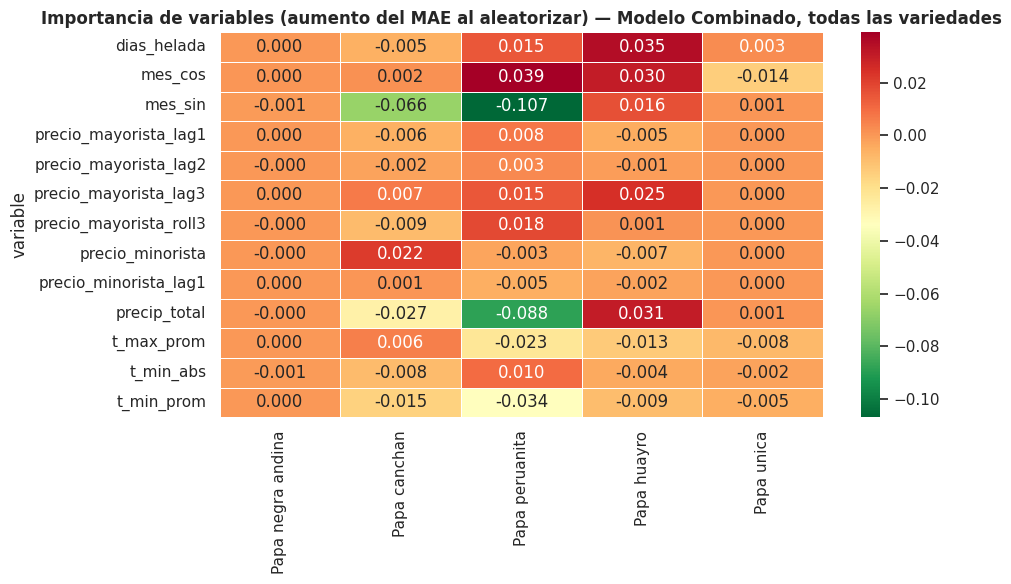

Importancia promedio de cada variable a través de las 5 variedades modeladas:


,aumento_MAE_promedio
variable,
mes_cos,0.0115
dias_helada,0.0095
precio_mayorista_lag3,0.0093
precio_minorista,0.0024
precio_mayorista_roll3,0.0020
precio_mayorista_lag2,-0.0000
precio_mayorista_lag1,-0.0006
t_min_abs,-0.0010
precio_minorista_lag1,-0.0013


In [22]:
def permutation_importance_lstm(modelo, d, feature_names, n_repeats=15, seed=SEED):
    rng = np.random.default_rng(seed)
    Xte, yte, ts = d['Xte'], d['yte'], d['ts']
    base_pred = ts.inverse_transform(modelo.predict(Xte, verbose=0)).flatten()
    real = ts.inverse_transform(yte).flatten()
    base_mae = mean_absolute_error(real, base_pred)

    importancias = []
    for j, feat in enumerate(feature_names):
        errores = []
        for _ in range(n_repeats):
            X_perm = Xte.copy()
            flat = X_perm[:, :, j].flatten()
            rng.shuffle(flat)
            X_perm[:, :, j] = flat.reshape(X_perm[:, :, j].shape)
            pred_perm = ts.inverse_transform(modelo.predict(X_perm, verbose=0)).flatten()
            errores.append(mean_absolute_error(real, pred_perm))
        importancias.append(np.mean(errores) - base_mae)
    return pd.DataFrame({'variable': feature_names, 'aumento_MAE': importancias}).sort_values('aumento_MAE', ascending=False)

importancias_todas = {}
for producto in VARIEDADES_MODELABLES:
    imp = permutation_importance_lstm(modelos[producto]['Combinado'], datasets[producto]['Combinado'], COMBINADO_VARS)
    importancias_todas[producto] = imp.set_index('variable')['aumento_MAE']

imp_matriz = pd.DataFrame(importancias_todas)  # filas = variable, columnas = variedad

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(imp_matriz, annot=True, fmt='.3f', cmap='RdYlGn_r', linewidths=0.5, ax=ax)
ax.set_title('Importancia de variables (aumento del MAE al aleatorizar) — Modelo Combinado, todas las variedades')
plt.tight_layout(); plt.show()

importancia_promedio = imp_matriz.mean(axis=1).sort_values(ascending=False)
print("Importancia promedio de cada variable a través de las 5 variedades modeladas:")
display(importancia_promedio.to_frame('aumento_MAE_promedio').style.format('{:.4f}').background_gradient(cmap='RdYlGn_r'))

### 10.1. SHAP — estudio de caso detallado (Papa canchan)

SHAP es más costoso computacionalmente que Permutation Importance; se aplica aquí como **estudio de caso** sobre la variedad con mayor cobertura de datos (Papa canchan) para profundizar el análisis, mientras que la Permutation Importance de la celda anterior ya cubre el objetivo de interpretabilidad para las 5 variedades.

In [23]:
VARIEDAD_SHAP = 'Papa canchan' if 'Papa canchan' in VARIEDADES_MODELABLES else VARIEDADES_MODELABLES[0]
try:
    import shap
    background = datasets[VARIEDAD_SHAP]['Combinado']['Xtr'][:20]
    explainer = shap.GradientExplainer(modelos[VARIEDAD_SHAP]['Combinado'], background)
    shap_values = explainer.shap_values(datasets[VARIEDAD_SHAP]['Combinado']['Xte'][:10])
    sv = np.array(shap_values)
    if sv.ndim == 4:
        sv = sv[0]
    importancia_shap = np.abs(sv).mean(axis=(0, 1))
    shap_df = pd.DataFrame({'variable': COMBINADO_VARS, 'importancia_SHAP_media': importancia_shap}).sort_values(
        'importancia_SHAP_media', ascending=False)
    display(shap_df)
    print(f"✅ Análisis SHAP calculado correctamente sobre 10 muestras del conjunto de test de {VARIEDAD_SHAP}.")
except Exception as e:
    print("ℹ️ SHAP no pudo ejecutarse en este entorno (incompatibilidad de versiones TensorFlow/SHAP es común en Colab).")
    print(f"   Detalle técnico: {e}")
    print("   → La Permutation Importance de la celda anterior ya cubre el objetivo de interpretabilidad del modelo.")

ℹ️ SHAP no pudo ejecutarse en este entorno (incompatibilidad de versiones TensorFlow/SHAP es común en Colab).
   Detalle técnico: All arrays must be of the same length
   → La Permutation Importance de la celda anterior ya cubre el objetivo de interpretabilidad del modelo.


## 11. Interfaz interactiva: simulación "¿qué pasaría si...?"

Elige la variedad y luego ajusta los valores climáticos y económicos de los últimos 3 meses para obtener una predicción del precio mayorista del mes siguiente usando el **modelo combinado** ya entrenado para esa variedad.

In [24]:
selector_whatif = widgets.Dropdown(options=VARIEDADES_MODELABLES, value=VARIEDADES_MODELABLES[0], description='Variedad:')
out_whatif = widgets.Output()

def construir_whatif(producto):
    with out_whatif:
        clear_output(wait=True)
        panel_model = paneles_model[producto]
        ultimos3 = panel_model[COMBINADO_VARS].tail(WINDOW).reset_index(drop=True)

        sliders = {}
        caja_sliders = []
        for var in COMBINADO_VARS:
            if var in ('mes_sin', 'mes_cos'):
                continue  # se recalculan automáticamente según el mes elegido
            valor_actual = float(ultimos3[var].iloc[-1])
            rango = panel_model[var]
            s = widgets.FloatSlider(value=valor_actual, min=float(rango.min()), max=float(rango.max()) * 1.3,
                                     step=(rango.max() - rango.min()) / 100 or 0.01,
                                     description=var, style={'description_width': '160px'},
                                     layout=widgets.Layout(width='480px'))
            sliders[var] = s
            caja_sliders.append(s)

        mes_predecir = widgets.Dropdown(options=list(range(1, 13)), value=int(panel_model['mes'].iloc[-1]) % 12 + 1,
                                         description='Mes a predecir:', style={'description_width': '160px'})
        boton_predecir = widgets.Button(description='🔮 Predecir precio', button_style='success')
        out_pred = widgets.Output()

        def predecir_whatif(_):
            with out_pred:
                clear_output(wait=True)
                fila = ultimos3.copy()
                for var, s in sliders.items():
                    fila.loc[fila.index[-1], var] = s.value
                mes = mes_predecir.value
                fila.loc[fila.index[-1], 'mes_sin'] = np.sin(2 * np.pi * mes / 12)
                fila.loc[fila.index[-1], 'mes_cos'] = np.cos(2 * np.pi * mes / 12)

                X_input = fila[COMBINADO_VARS].values.astype(float)[np.newaxis, :, :]
                fs, ts = datasets[producto]['Combinado']['fs'], datasets[producto]['Combinado']['ts']
                X_scaled = fs.transform(X_input.reshape(-1, X_input.shape[2])).reshape(X_input.shape)
                pred_escalado = modelos[producto]['Combinado'].predict(X_scaled, verbose=0)
                pred = ts.inverse_transform(pred_escalado).flatten()[0]

                print(f"💰 Precio mayorista predicho de {producto} para el mes {mes}: S/ {pred:.2f} por kg")
                print(f"   (último precio observado: S/ {panel_model['precio_mayorista'].iloc[-1]:.2f} por kg)")

        boton_predecir.on_click(predecir_whatif)
        display(widgets.VBox(caja_sliders + [mes_predecir, boton_predecir, out_pred]))

def on_change_whatif(change):
    construir_whatif(change['new'])

selector_whatif.observe(on_change_whatif, names='value')
display(selector_whatif, out_whatif)
construir_whatif(VARIEDADES_MODELABLES[0])

Dropdown(description='Variedad:', options=('Papa negra andina', 'Papa canchan', 'Papa peruanita', 'Papa huayro…

Output()

## 12. Conclusiones y limitaciones del prototipo

**Resumen del pipeline:** este notebook integró precios SISAP‑MIDAGRI (mayorista/minorista) y clima SENAMHI (estación Puente Ilave) en un panel mensual 2020‑2025 para las **6 variedades de papa** disponibles, entrenó tres LSTM (climático, económico, combinado) **para cada una de las 5 variedades con datos suficientes** (15 modelos en total) y los comparó contra un baseline de persistencia usando MAE, RMSE, MAPE y R², además de un análisis de importancia de variables replicado en todas ellas.

**Limitaciones a tener en cuenta al redactar el capítulo de resultados de la tesis:**

1. **Tamaño de muestra reducido.** Cada variedad dispone de ~69 observaciones mensuales tras la ingeniería de lags, de las cuales apenas ~10 quedan en el conjunto de test. Los resultados de este prototipo son ilustrativos del *pipeline metodológico*, no una validación estadísticamente concluyente de la hipótesis de investigación.
2. **Papa yungay excluida del modelado.** Solo ~19% de sus meses tienen dato real de mercado (el resto se interpoló); entrenar una LSTM sobre una serie mayoritariamente interpolada produciría una validación artificialmente optimista. Se recomienda gestionar la obtención de más historia real para esta variedad antes de modelarla.
3. **Variables económicas incompletas.** La tesis contempla IPC, costos de producción/transporte y volumen de ingreso a mercados (BCRP/INEI); este prototipo solo usa precios SISAP como proxy económico. Integrar esas series (sección 3.2) fortalecerá el modelo "Económico" y "Combinado" en las 5 variedades.
4. **Una sola estación meteorológica.** Puente Ilave puede no representar la variabilidad climática de todas las provincias productoras de papa en Puno; si SENAMHI dispone de más estaciones, un promedio ponderado por zona productora mejoraría la señal climática para todas las variedades.
5. **Frecuencia mensual.** Si se consigue el precio a frecuencia semanal o quincenal (SISAP suele reportar diario/semanal a nivel de mercado), el número de secuencias de entrenamiento aumentaría sustancialmente, algo muy valioso para una LSTM.

**Próximos pasos sugeridos:** (a) walk‑forward cross‑validation en vez de un único split, replicada por variedad; (b) incorporar IPC/BCRP; (c) probar variantes con mecanismo de atención (mencionado en el marco teórico de la tesis, sección 2.2.6.3); (d) reintentar Papa yungay si SISAP publica más historia real; (e) explorar un modelo multi‑salida (una sola LSTM que prediga las 5 variedades a la vez) para comparar contra el enfoque actual de un modelo por variedad.